## Graphs for multi-label classification

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    'font.size': 12,          # Base font size for regular text
    'axes.titlesize': 16,     # Font size for the plot title (Panel A, Panel B)
    'axes.labelsize': 14,     # Font size for X and Y axis labels (Epoch, Metric)
    'xtick.labelsize': 12,    # Font size for the X-axis numbers (1, 2, 3...)
    'ytick.labelsize': 12,    # Font size for the Y-axis numbers (0.5, 1.0...)
    'legend.fontsize': 11,    # Font size for the legend text
    'figure.titlesize': 18    # Font size for the main overarching figure title
})

### First try baseline

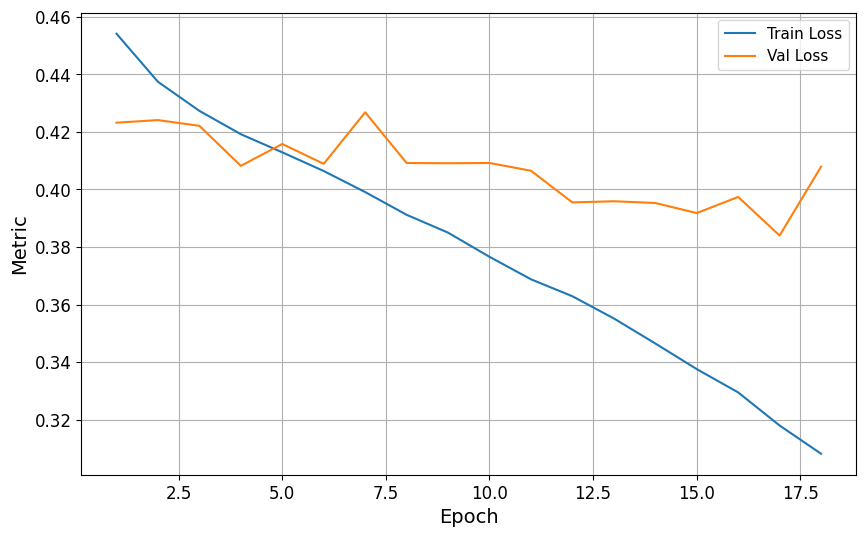

In [3]:
epochs_1 = np.arange(1, 19, 1)
train_loss_1 = np.array([0.4541, 0.4374, 0.4273, 0.4192, 0.4129, 0.4064, 0.3991, 0.3912, 0.3850, 0.3766, 0.3688, 0.3629, 0.3552, 0.3465, 0.3376, 0.3295, 0.3180, 0.3082])
val_loss_1 = np.array([0.4232, 0.4241, 0.4221, 0.4082, 0.4158, 0.4089, 0.4268, 0.4092, 0.4091, 0.4092, 0.4065, 0.3955, 0.3959, 0.3953, 0.3918, 0.3974, 0.3840, 0.4079])

plt.figure(figsize=(10,6))

plt.plot(epochs_1, train_loss_1, label="Train Loss")
plt.plot(epochs_1, val_loss_1, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)

plt.show()

## Second try baseline

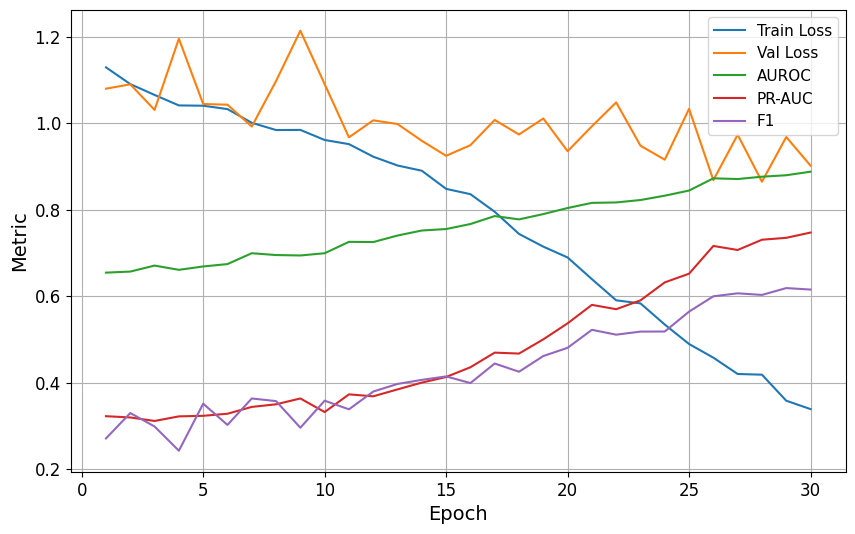

In [4]:
epochs_2 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])
train_loss_2 = np.array([
    1.1290, 1.0903, 1.0652, 1.0410, 1.0403,
    1.0325, 1.0008, 0.9841, 0.9844, 0.9611,
    0.9515, 0.9225, 0.9021, 0.8900, 0.8481,
    0.8358, 0.7951, 0.7439, 0.7145, 0.6895,
    0.6394, 0.5904, 0.5833, 0.5344, 0.4894,
    0.4578, 0.4201, 0.4185, 0.3583, 0.3389
])
val_loss_2 = np.array([
    1.0797, 1.0898, 1.0306, 1.1953, 1.0442,
    1.0427, 0.9922, 1.0975, 1.2137, 1.0902,
    0.9672, 1.0065, 0.9980, 0.9592, 0.9245,
    0.9491, 1.0074, 0.9738, 1.0108, 0.9352,
    0.9927, 1.0480, 0.9479, 0.9155, 1.0331,
    0.8682, 0.9733, 0.8646, 0.9680, 0.9018
])
auroc_2 = np.array([
    0.6544, 0.6569, 0.6707, 0.6609, 0.6687,
    0.6742, 0.6993, 0.6951, 0.6941, 0.6993,
    0.7256, 0.7251, 0.7402, 0.7518, 0.7552,
    0.7668, 0.7852, 0.7775, 0.7898, 0.8038,
    0.8157, 0.8167, 0.8223, 0.8323, 0.8442,
    0.8725, 0.8708, 0.8762, 0.8796, 0.8878
])
pr_auc_2 = np.array([
    0.3225, 0.3196, 0.3115, 0.3221, 0.3234,
    0.3282, 0.3440, 0.3500, 0.3635, 0.3321,
    0.3730, 0.3685, 0.3845, 0.4002, 0.4131,
    0.4357, 0.4695, 0.4673, 0.5002, 0.5372,
    0.5799, 0.5699, 0.5903, 0.6319, 0.6520,
    0.7161, 0.7068, 0.7305, 0.7349, 0.7471
])
f1_2 = np.array([
    0.2712, 0.3298, 0.2987, 0.2427, 0.3514,
    0.3024, 0.3635, 0.3574, 0.2959, 0.3584,
    0.3384, 0.3795, 0.3971, 0.4065, 0.4145,
    0.3991, 0.4443, 0.4253, 0.4616, 0.4806,
    0.5222, 0.5110, 0.5181, 0.5183, 0.5643,
    0.5997, 0.6066, 0.6029, 0.6187, 0.6153
])

plt.figure(figsize=(10,6))

plt.plot(epochs_2, train_loss_2, label="Train Loss")
plt.plot(epochs_2, val_loss_2, label="Val Loss")
plt.plot(epochs_2, auroc_2, label="AUROC")
plt.plot(epochs_2, pr_auc_2, label="PR-AUC")
plt.plot(epochs_2, f1_2, label="F1")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)

plt.show()

## Fix data leakage 

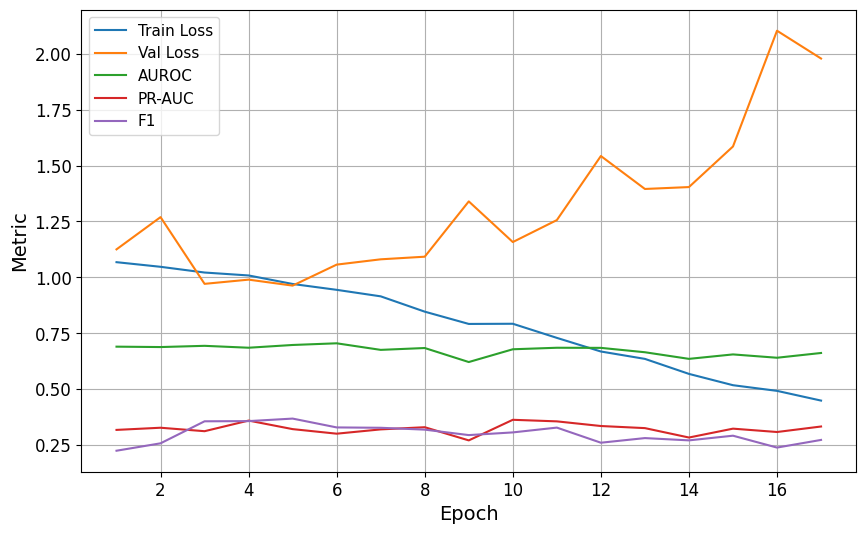

In [5]:
epochs_3 = np.array([
    1, 2, 3, 4, 5, 6, 7, 8, 9,
    10, 11, 12, 13, 14, 15, 16, 17
])

train_loss_3 = np.array([
    1.0678, 1.0471, 1.0215, 1.0084, 0.9703,
    0.9441, 0.9150, 0.8465, 0.7916,
    0.7924, 0.7293, 0.6683, 0.6353,
    0.5682, 0.5176, 0.4923, 0.4488
])

val_loss_3  = np.array([
    1.1251, 1.2693, 0.9709, 0.9897, 0.9630,
    1.0569, 1.0806, 1.0923, 1.3396,
    1.1578, 1.2560, 1.5426, 1.3952,
    1.4037, 1.5852, 2.1029, 1.9785
])

auroc_3 = np.array([
    0.6900, 0.6882, 0.6937, 0.6852, 0.6975,
    0.7050, 0.6756, 0.6839, 0.6212,
    0.6783, 0.6851, 0.6846, 0.6650,
    0.6354, 0.6553, 0.6404, 0.6617
])

pr_auc_3 = np.array([
    0.3177, 0.3274, 0.3119, 0.3594, 0.3212,
    0.3008, 0.3200, 0.3297, 0.2708,
    0.3629, 0.3559, 0.3351, 0.3257,
    0.2836, 0.3233, 0.3083, 0.3329
])

f1_3 = np.array([
    0.2246, 0.2577, 0.3562, 0.3570, 0.3683,
    0.3288, 0.3272, 0.3189, 0.2945,
    0.3065, 0.3280, 0.2604, 0.2811,
    0.2709, 0.2918, 0.2387, 0.2729
])

plt.figure(figsize=(10,6))

plt.plot(epochs_3, train_loss_3, label="Train Loss")
plt.plot(epochs_3, val_loss_3, label="Val Loss")
plt.plot(epochs_3, auroc_3, label="AUROC")
plt.plot(epochs_3, pr_auc_3, label="PR-AUC")
plt.plot(epochs_3, f1_3, label="F1")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)

plt.show()

## Different Windowing

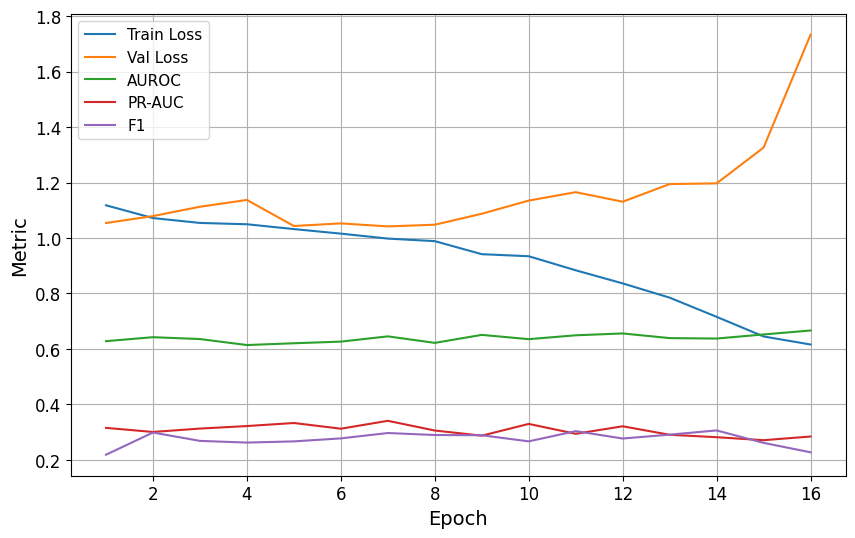

In [6]:
epochs_4 = np.array([
    1, 2, 3, 4, 5, 6, 7, 8,
    9, 10, 11, 12, 13, 14, 15, 16
])

train_loss_4 = np.array([
    1.1179, 1.0718, 1.0543, 1.0495,
    1.0321, 1.0157, 0.9978, 0.9886,
    0.9416, 0.9342, 0.8835, 0.8362,
    0.7848, 0.7156, 0.6448, 0.6158
])

val_loss_4 = np.array([
    1.0540, 1.0790, 1.1127, 1.1372,
    1.0432, 1.0527, 1.0417, 1.0479,
    1.0874, 1.1349, 1.1652, 1.1308,
    1.1944, 1.1970, 1.3260, 1.7331
])

auroc_4 = np.array([
    0.6279, 0.6422, 0.6355, 0.6139,
    0.6203, 0.6262, 0.6452, 0.6217,
    0.6505, 0.6351, 0.6490, 0.6557,
    0.6389, 0.6373, 0.6521, 0.6663
])

pr_auc_4 = np.array([
    0.3151, 0.3004, 0.3126, 0.3217,
    0.3327, 0.3122, 0.3406, 0.3056,
    0.2870, 0.3294, 0.2938, 0.3209,
    0.2902, 0.2815, 0.2707, 0.2840
])

f1_4 = np.array([
    0.2183, 0.2983, 0.2682, 0.2621,
    0.2664, 0.2772, 0.2966, 0.2894,
    0.2885, 0.2665, 0.3034, 0.2767,
    0.2907, 0.3059, 0.2611, 0.2270
])

plt.figure(figsize=(10,6))

plt.plot(epochs_4, train_loss_4, label="Train Loss")
plt.plot(epochs_4, val_loss_4, label="Val Loss")
plt.plot(epochs_4, auroc_4, label="AUROC")
plt.plot(epochs_4, pr_auc_4, label="PR-AUC")
plt.plot(epochs_4, f1_4, label="F1")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)

plt.show()

## Train Loss

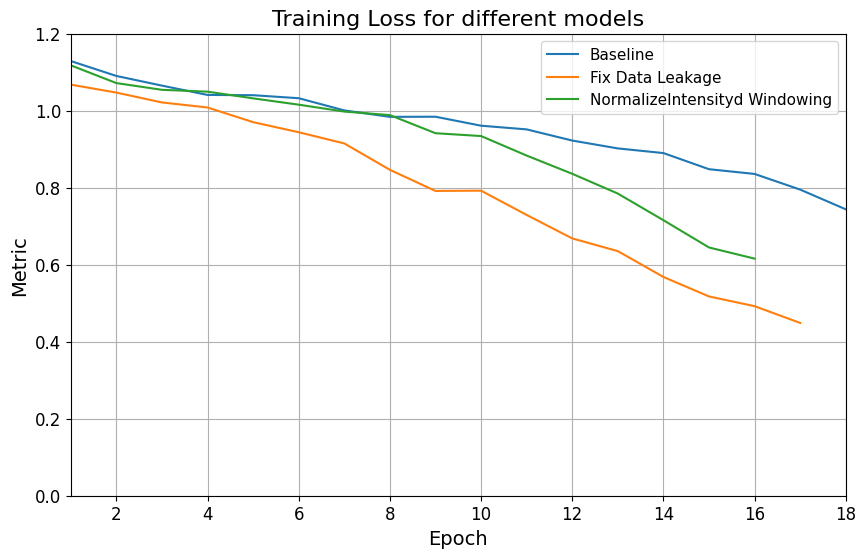

In [7]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, train_loss_2, label="Baseline")
plt.plot(epochs_3, train_loss_3, label="Fix Data Leakage")
plt.plot(epochs_4, train_loss_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('Training Loss for different models')
plt.legend()
plt.xlim(1, 18)
plt.ylim(0, 1.2)
plt.grid(True)

plt.show()

## Validation Loss

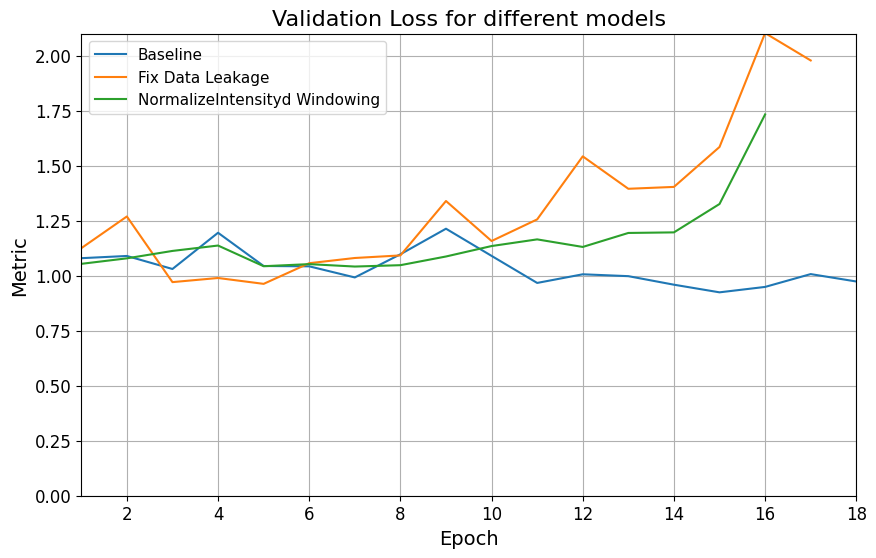

In [8]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, val_loss_2, label="Baseline")
plt.plot(epochs_3, val_loss_3, label="Fix Data Leakage")
plt.plot(epochs_4, val_loss_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('Validation Loss for different models')
plt.legend()
plt.xlim(1, 18)
plt.ylim(0, 2.1)
plt.grid(True)

plt.show()

## AUROC

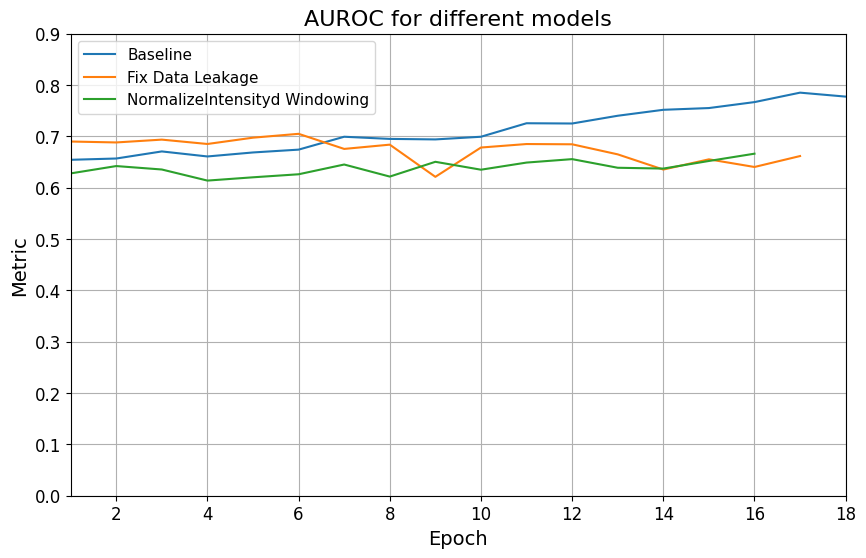

In [9]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, auroc_2, label="Baseline")
plt.plot(epochs_3, auroc_3, label="Fix Data Leakage")
plt.plot(epochs_4, auroc_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('AUROC for different models')
plt.xlim(1, 18)
plt.ylim(0, 0.9)
plt.legend()
plt.grid(True)

plt.show()

## pr-auc

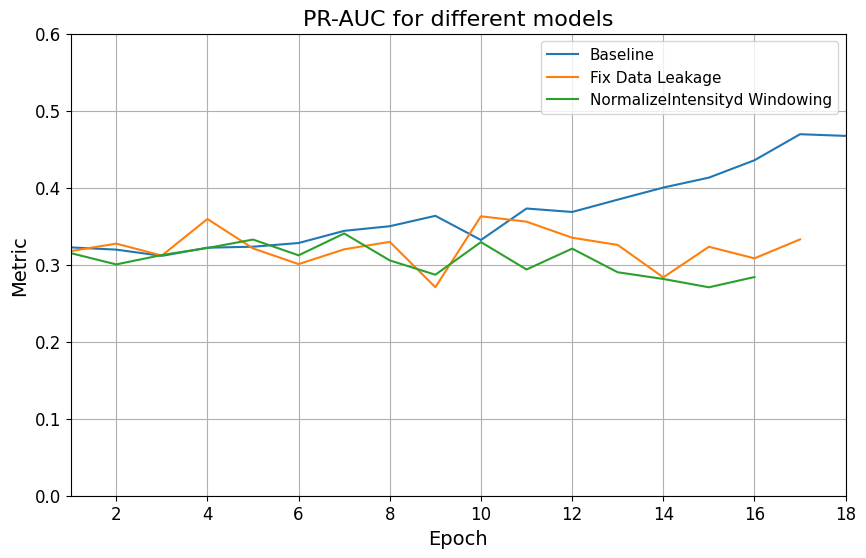

In [10]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, pr_auc_2, label="Baseline")
plt.plot(epochs_3, pr_auc_3, label="Fix Data Leakage")
plt.plot(epochs_4, pr_auc_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('PR-AUC for different models')
plt.legend()
plt.xlim(1, 18)
plt.ylim(0, 0.6)
plt.grid(True)

plt.show()

## F1 - Score

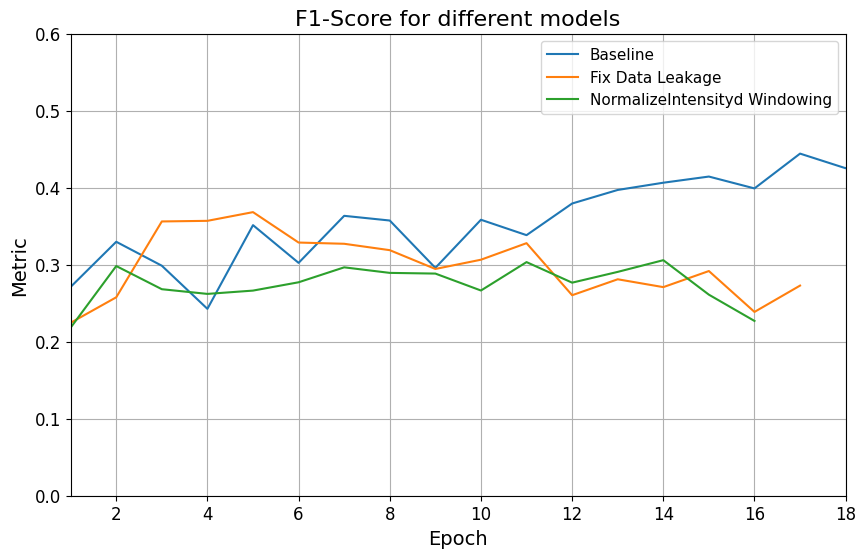

In [11]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, f1_2, label="Baseline")
plt.plot(epochs_3, f1_3, label="Fix Data Leakage")
plt.plot(epochs_4, f1_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('F1-Score for different models')
plt.legend()
plt.xlim(1, 18)
plt.ylim(0, 0.6)
plt.grid(True)

plt.show()

## Heatmap

In [12]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from monai.networks.nets import resnet50
from monai.visualize import GradCAM
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd, Resized, NormalizeIntensityd, EnsureTyped


c:\Users\alvap\OneDrive\Documents\MSc\Data-Challenges_RDGY41850\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
#set up device and load the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet50(spatial_dims=3, n_input_channels=1, num_classes=18).to(device)

#load saved weights from training
model.load_state_dict(torch.load("../Weights_best_models/resnet50_v2_best.pth", map_location=device))
model.eval()

#initialise GradCAM with the model and target layer
#layer4 is final convolutional layer in resnet50
cam = GradCAM(nn_module=model, target_layers="layer4")

#load a single sample volume
test_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(
        keys=["image"],
        pixdim=(2.0, 2.0, 2.0),
        mode="bilinear"
    ),
    Resized(
        keys=["image"],
        spatial_size=(128, 128, 128)
    ),
    NormalizeIntensityd(
        keys=["image"],
        nonzero=True
    ),
    EnsureTyped(keys=["image"])
])
sample_data = test_transforms({'image': "../dataset/CT-RATE-sample/dataset/train/train_1/train_1_a/train_1_a_1.nii.gz"})
input_tensor = sample_data["image"].unsqueeze(0).to(device)

In [17]:
#check what abnormalities are present in the sample
# Load the spreadsheet
csv_path = "../dataset/CT-RATE-sample/dataset/multi_abnormality_labels/train_predicted_labels.csv"
df = pd.read_csv(csv_path)

# Look for the row that matches file
# Add the extension to your search string
patient_id = "train_1_a_1.nii.gz"
patient_row = df[df['VolumeName'] == patient_id]

print(f"Findings for {patient_id}:")
# Setting transpose (.T) makes it much easier to read the list of diseases
print(patient_row.T)

Findings for train_1_a_1.nii.gz:
                                                     0
VolumeName                          train_1_a_1.nii.gz
Medical material                                     0
Arterial wall calcification                          1
Cardiomegaly                                         0
Pericardial effusion                                 0
Coronary artery wall calcification                   0
Hiatal hernia                                        0
Lymphadenopathy                                      0
Emphysema                                            0
Atelectasis                                          1
Lung nodule                                          0
Lung opacity                                         1
Pulmonary fibrotic sequela                           0
Pleural effusion                                     0
Mosaic attenuation pattern                           0
Peribronchial thickening                             1
Consolidation                   

In [42]:
# generate 3D heatmaps for two different diseases
# 1 = Arterial wall calcification, 15 = Consolidation
target_classes = {"Calcification": 1, "Consolidation": 15}
heatmaps = {}

for class_name, class_idx in target_classes.items():
    heatmap_3d = cam(x=input_tensor, class_idx=class_idx)
    heatmaps[class_name] = heatmap_3d[0, 0].cpu().numpy()

image_np = input_tensor[0, 0].cpu().numpy()

#extract middle slise 
slice_idx = image_np.shape[2] // 2
img_slice = image_np[:, :, slice_idx]

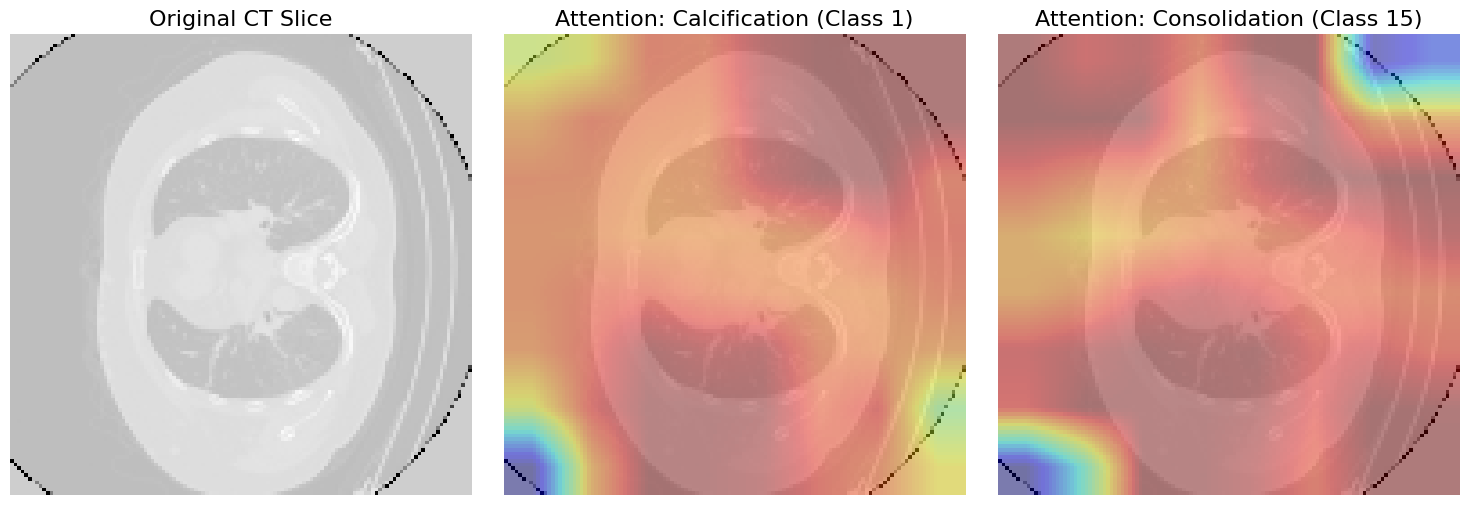

In [43]:
# plot a 1-row, 3-column comparison figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# extract the matching middle slice for both heatmaps
map_calcification = heatmaps["Calcification"][:, :, slice_idx]
map_consolidation = heatmaps["Consolidation"][:, :, slice_idx]

#  1 - Original Image
axes[0].imshow(img_slice, cmap="gray")
axes[0].set_title("Original CT Slice")
axes[0].axis("off")

# 2 - Calcification Attention
axes[1].imshow(img_slice, cmap="gray")
axes[1].imshow(map_calcification, cmap="jet", alpha=0.4)
axes[1].set_title("Attention: Calcification (Class 1)")
axes[1].axis("off")



# 3 - Consolidation Attention
axes[2].imshow(img_slice, cmap="gray")
axes[2].imshow(map_consolidation, cmap="jet", alpha=0.4)
axes[2].set_title("Attention: Consolidation (Class 15)")
axes[2].axis("off")

plt.tight_layout()